# Fase 2 v4 — NB01: Gold Multi-etiqueta

Notebook único del gold: **muestreo** (Pool A representativo + Pool B minado), generación de la
**plantilla de anotación**, y **consolidación** de las 3 anotaciones (Fleiss/Cohen κ + mayoría).

**Idempotente:** si el gold ya existe, se cargan los pools **sin re-muestrear** (no se tocan las
anotaciones). Así se corre 1ª vez para generar la plantilla, se anota, y se re-corre para consolidar.
*No se entrena ningún modelo aquí; el esquema multi-etiqueta valida la detección (NB02) y entrena la polaridad (NB03).*

## 1. Configuración y carga del corpus

In [1]:
import json, random
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)

BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
GOLD_DIR = BASE_DIR / "outputs" / "gold"
GOLD_DIR.mkdir(parents=True, exist_ok=True)

# Parámetros del muestreo
N_POOL_A = 40          # reseñas por centro (representativo)
N_POOL_B = 30          # reseñas por centro (minado, según disponibilidad)
ANOTADORES = ["anotador_1", "anotador_2", "anotador_3"]

ASPECTOS = ["atractivos", "costos", "seguridad", "accesibilidad",
            "limpieza", "atencion_servicio", "gastronomia", "alojamiento"]
VALORES_PERMITIDOS = ["ausente", "negativo", "neutro", "positivo"]

corpus = pd.read_csv(DATA_DIR / "tourism_reviews_clean.csv", encoding="utf-8-sig")
print("Corpus limpio:", corpus.shape, "| centros:", corpus["destination"].nunique())
print("Aspectos:", ASPECTOS)

Corpus limpio: (13740, 13) | centros: 15
Aspectos: ['atractivos', 'costos', 'seguridad', 'accesibilidad', 'limpieza', 'atencion_servicio', 'gastronomia', 'alojamiento']


## 2. Muestreo del gold (idempotente: Pool A + Pool B)

In [2]:
PLANTILLA_PATH = GOLD_DIR / "plantilla_gold_multietiqueta.csv"
if PLANTILLA_PATH.exists():
    plantilla = pd.read_csv(PLANTILLA_PATH, encoding="utf-8-sig")
    pool_A = plantilla[plantilla["pool"] == "A_representativo"].copy()
    pool_B = plantilla[plantilla["pool"] == "B_minado"].copy()
    print("Gold YA existe -> se cargan los pools sin re-muestrear (anotaciones intactas):",
          {"Pool A": len(pool_A), "Pool B": len(pool_B)})
else:
    # POOL A — REPRESENTATIVO (aleatorio estratificado por centro)
    _parts = []
    for _d, _g in corpus.groupby("destination"):
        _parts.append(_g.sample(n=min(N_POOL_A, len(_g)), random_state=SEED))
    pool_A = pd.concat(_parts, ignore_index=True)
    pool_A["pool"] = "A_representativo"
    print("Pool A:", len(pool_A), "reseñas (", N_POOL_A, "por centro)")
    display(pool_A.groupby("destination").size().rename("n_pool_A").reset_index())
    
    # POOL B — MINADO (negativas/neutras: estrellas bajas + pistas léxicas)
    PISTAS_NEG = [
        "caro", "carisimo", "sobreprecio", "sucio", "basura", "robo", "roban", "peligro",
        "inseguro", "cola", "fila", "demora", "espera", "lento", "malo", "pesimo", "terrible",
        "horrible", "deplorable", "decepcion", "estafa", "grosero", "feo", "desorganiz", "no vale",
        "expensive", "overpriced", "dirty", "trash", "robbery", "unsafe", "dangerous", "queue",
        "line", "slow", "rude", "bad", "worst", "awful", "terrible", "disappoint", "scam", "crowded",
    ]
    texto_low = corpus["text_clean"].astype(str).str.lower()
    tiene_pista = texto_low.apply(lambda t: any(p in t for p in PISTAS_NEG))
    stars = pd.to_numeric(corpus["stars"], errors="coerce")
    
    # Candidatos: NO están en Pool A, y (estrellas <= 3 O tienen pista negativa)
    en_A = corpus["review_uid"].isin(pool_A["review_uid"])
    cand = corpus[(~en_A) & ((stars <= 3) | tiene_pista)].copy()
    cand["_prioridad"] = np.where(pd.to_numeric(cand["stars"], errors="coerce") <= 2, 0,
                           np.where(pd.to_numeric(cand["stars"], errors="coerce") == 3, 1, 2))
    
    # Muestreo por centro: prioriza estrellas 1-2, luego 3, luego pista en estrellas altas
    _parts_b = []
    for _d, _g in cand.groupby("destination"):
        _g2 = _g.sort_values("_prioridad").head(N_POOL_B * 3)   # pool de prioridad
        _parts_b.append(_g2.sample(n=min(N_POOL_B, len(_g2)), random_state=SEED))
    pool_B = pd.concat(_parts_b, ignore_index=True).drop(columns=["_prioridad"])
    pool_B["pool"] = "B_minado"
    print("Pool B:", len(pool_B), "reseñas")
    print("Distribución de estrellas en Pool B:")
    display(pd.to_numeric(pool_B["stars"], errors="coerce").value_counts().sort_index().rename_axis("estrellas").reset_index(name="n"))
    display(pool_B.groupby("destination").size().rename("n_pool_B").reset_index())
    
    # PLANTILLA MULTI-ETIQUETA + COPIAS POR ANOTADOR
    COLS_BASE = ["review_uid", "destination", "source", "language_review", "stars",
                 "publishedAtDate", "text_clean", "pool"]
    COLS_BASE = [c for c in COLS_BASE if c in pool_A.columns]
    
    plantilla = pd.concat([pool_A, pool_B], ignore_index=True)[COLS_BASE].copy()
    plantilla = plantilla.drop_duplicates(subset="review_uid").reset_index(drop=True)
    
    # Columnas de aspecto pre-llenadas con "ausente" (el anotador solo cambia las presentes)
    for a in ASPECTOS:
        plantilla[a] = "ausente"
    
    plantilla.to_csv(GOLD_DIR / "plantilla_gold_multietiqueta.csv", index=False, encoding="utf-8-sig")
    
    # Copia independiente para cada juez
    for anot in ANOTADORES:
        p = plantilla.copy()
        p["anotador"] = anot
        p.to_csv(GOLD_DIR / f"{anot}.csv", index=False, encoding="utf-8-sig")
    
    # Instrucciones para los jueces
    instrucciones = (
        "INSTRUCCIONES DE ANOTACION — Gold set multi-etiqueta (Fase 2)\n"
        "============================================================\n\n"
        "Por cada reseña, revisa el texto (columna text_clean) y para CADA uno de los 8 aspectos\n"
        "marca uno de estos valores en su columna:\n"
        "   ausente  = la reseña NO habla de ese aspecto\n"
        "   negativo = lo menciona de forma NEGATIVA\n"
        "   neutro   = lo menciona de forma NEUTRA / mixta / informativa\n"
        "   positivo = lo menciona de forma POSITIVA\n\n"
        "Aspectos: " + ", ".join(ASPECTOS) + "\n\n"
        "Reglas:\n"
        " - La mayoria de aspectos quedaran en 'ausente' (ya vienen pre-llenados); solo cambia los que la resena toca.\n"
        " - clima y aforo NO son aspectos aqui (son contexto en Fase 4).\n"
        " - No cambies las columnas base (review_uid, text_clean, etc.).\n"
        " - Anota de forma independiente; no copies de otro anotador.\n"
    )
    (GOLD_DIR / "instrucciones_anotacion.txt").write_text(instrucciones, encoding="utf-8")
    
    print("Plantilla:", plantilla.shape)
    print("Archivos generados en outputs/gold/:")
    print(" - plantilla_gold_multietiqueta.csv (maestro)")
    for anot in ANOTADORES:
        print(f" - {anot}.csv")
    print(" - instrucciones_anotacion.txt")
    display(plantilla.head())

Gold YA existe -> se cargan los pools sin re-muestrear (anotaciones intactas): {'Pool A': 600, 'Pool B': 450}


## 2b. Protección de sincronización gold ↔ corpus

In [3]:
# ============================================================
# PROTECCIÓN: el gold debe pertenecer al CORPUS ACTUAL de Fase 1
# ============================================================
# Si Fase 1 cambia (umbral, limpieza, dedup), las reseñas del gold deben seguir
# existiendo en el corpus vigente. Este chequeo lo verifica por review_uid y
# DETIENE la ejecución si hay desincronización.
corpus_uids = set(corpus["review_uid"])
gold_uids = set(plantilla["review_uid"]) if "plantilla" in dir() else (set(pool_A["review_uid"]) | set(pool_B["review_uid"]))
faltan = gold_uids - corpus_uids
print("Sincronización gold <-> corpus de Fase 1:")
print(f"  corpus actual: {len(corpus_uids)} reseñas  |  gold: {len(gold_uids)} reseñas")
print(f"  gold presentes en el corpus actual: {len(gold_uids & corpus_uids)}/{len(gold_uids)}")
assert len(faltan) == 0, (
    f"DESINCRONIZADO: {len(faltan)} reseñas del gold NO están en el corpus actual de Fase 1. "
    "El gold se anotó sobre un corpus distinto -> regenera/realinea antes de seguir.")
print("  OK: el gold pertenece al corpus actual. Sincronizado.")

Sincronización gold <-> corpus de Fase 1:
  corpus actual: 13740 reseñas  |  gold: 1050 reseñas
  gold presentes en el corpus actual: 1050/1050
  OK: el gold pertenece al corpus actual. Sincronizado.


## 3. Figuras de los pools

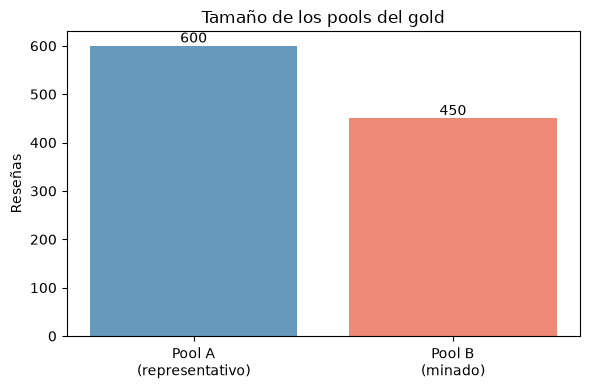

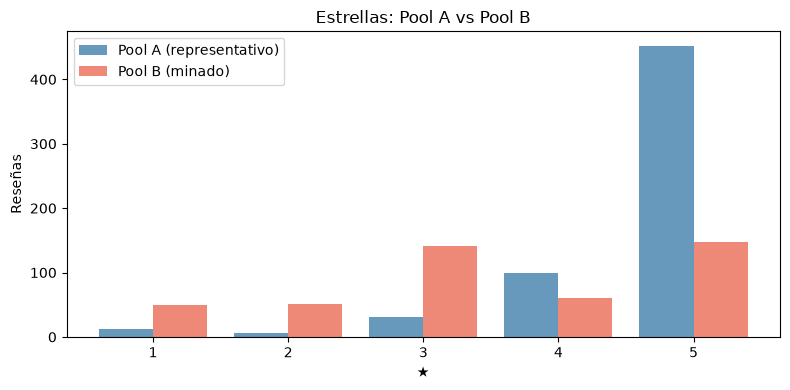

Figuras NB01 -> outputs/figures/


In [4]:
# ============================================================
# VISUALIZACIONES (figuras para la tesis)
# ============================================================
import matplotlib.pyplot as plt
FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

# 1) Tamaño de pools
plt.figure(figsize=(6, 4))
vals = [len(pool_A), len(pool_B)]
plt.bar(["Pool A\n(representativo)", "Pool B\n(minado)"], vals, color=["#6699bb", "#ee8877"])
for i, v in enumerate(vals): plt.text(i, v, str(v), ha="center", va="bottom")
plt.ylabel("Reseñas"); plt.title("Tamaño de los pools del gold")
plt.tight_layout(); plt.savefig(FIG / "fase2_gold_pools.png", dpi=300); plt.show()

# 2) Estrellas Pool A vs Pool B (muestra que el minado trajo negativos/neutros)
sa = pd.to_numeric(pool_A["stars"], errors="coerce").value_counts().sort_index()
sb = pd.to_numeric(pool_B["stars"], errors="coerce").value_counts().sort_index()
idx = sorted(set(sa.index) | set(sb.index))
x = np.arange(len(idx)); w = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, [sa.get(i, 0) for i in idx], w, label="Pool A (representativo)", color="#6699bb")
plt.bar(x + w/2, [sb.get(i, 0) for i in idx], w, label="Pool B (minado)", color="#ee8877")
plt.xticks(x, [str(int(i)) for i in idx]); plt.xlabel("★"); plt.ylabel("Reseñas")
plt.title("Estrellas: Pool A vs Pool B"); plt.legend()
plt.tight_layout(); plt.savefig(FIG / "fase2_gold_estrellas_pools.png", dpi=300); plt.show()
print("Figuras NB01 -> outputs/figures/")

## 4. Consolidación — carga de las 3 anotaciones

In [5]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
GOLD_DIR = BASE_DIR / "outputs" / "gold"

ASPECTOS = ["atractivos", "costos", "seguridad", "accesibilidad",
            "limpieza", "atencion_servicio", "gastronomia", "alojamiento"]
CATEGORIAS = ["ausente", "negativo", "neutro", "positivo"]
ANOTADORES = ["anotador_1", "anotador_2", "anotador_3"]

dfs = {a: pd.read_csv(GOLD_DIR / f"{a}.csv", encoding="utf-8-sig").set_index("review_uid") for a in ANOTADORES}
n_reseñas = len(dfs["anotador_1"])
print("Reseñas anotadas:", n_reseñas, "| aspectos:", len(ASPECTOS), "| celdas/anotador:", n_reseñas * len(ASPECTOS))

# Tabla larga: una fila por (review_uid, aspecto) con las 3 etiquetas alineadas por review_uid.
base = dfs["anotador_1"].reset_index()[["review_uid", "destination", "text_clean", "pool", "stars"]].copy()
largo = []
for a in ASPECTOS:
    sub = base.copy()
    sub["aspecto"] = a
    for anot in ANOTADORES:
        sub[anot] = dfs[anot][a].reindex(base["review_uid"]).values
    largo.append(sub)
largo = pd.concat(largo, ignore_index=True)
print("Celdas totales (reseña x aspecto):", len(largo))

Reseñas anotadas: 1050 | aspectos: 8 | celdas/anotador: 8400
Celdas totales (reseña x aspecto): 8400


## 5. Acuerdo interanotador (Fleiss / Cohen)

In [6]:
# ============================================================
# ACUERDO INTERANOTADOR
# ============================================================
def fleiss_kappa(matrix):
    """matrix: n_items x n_categorias con el conteo de jueces por categoría."""
    matrix = np.asarray(matrix, dtype=float)
    n_items, n_cat = matrix.shape
    n_raters = matrix.sum(axis=1)[0]
    p_j = matrix.sum(axis=0) / (n_items * n_raters)
    P_i = (np.square(matrix).sum(axis=1) - n_raters) / (n_raters * (n_raters - 1))
    P_bar = P_i.mean()
    P_e = np.square(p_j).sum()
    return (P_bar - P_e) / (1 - P_e) if (1 - P_e) != 0 else np.nan

def matriz_conteo(df):
    M = np.zeros((len(df), len(CATEGORIAS)))
    for i, (_, row) in enumerate(df.iterrows()):
        for anot in ANOTADORES:
            M[i, CATEGORIAS.index(row[anot])] += 1
    return M

# Fleiss global
fleiss_global = fleiss_kappa(matriz_conteo(largo))
print(f"Fleiss κ GLOBAL (4 categorías): {fleiss_global:.4f}")

# Fleiss por aspecto
filas_k = []
for a in ASPECTOS:
    sub = largo[largo["aspecto"] == a]
    filas_k.append({"aspecto": a, "fleiss_kappa": round(fleiss_kappa(matriz_conteo(sub)), 4)})
kappa_aspecto = pd.DataFrame(filas_k).sort_values("fleiss_kappa", ascending=False)
display(kappa_aspecto)

# Cohen κ por pares (sobre el vector plano de etiquetas)
print("Cohen κ por pares:")
for i in range(len(ANOTADORES)):
    for j in range(i + 1, len(ANOTADORES)):
        k = cohen_kappa_score(largo[ANOTADORES[i]], largo[ANOTADORES[j]])
        print(f"  {ANOTADORES[i]} vs {ANOTADORES[j]}: {k:.4f}")

# Acuerdo de PRESENCIA (binario: ausente vs presente) — clave para la detección (ACD)
pres = largo[ANOTADORES].apply(lambda col: col != "ausente")
M_pres = np.zeros((len(largo), 2))
M_pres[:, 0] = (~pres).sum(axis=1)   # ausente
M_pres[:, 1] = pres.sum(axis=1)      # presente
print(f"\nFleiss κ de PRESENCIA (ausente vs presente): {fleiss_kappa(M_pres):.4f}")

Fleiss κ GLOBAL (4 categorías): 0.8612


,aspecto,fleiss_kappa
4,limpieza,0.9180
6,gastronomia,0.8869
2,seguridad,0.8786
7,alojamiento,0.8499
1,costos,0.8484
5,atencion_servicio,0.8357
3,accesibilidad,0.7698
0,atractivos,0.7290


Cohen κ por pares:


  anotador_1 vs anotador_2: 0.8065
  anotador_1 vs anotador_3: 0.9781
  anotador_2 vs anotador_3: 0.7965

Fleiss κ de PRESENCIA (ausente vs presente): 0.9589


## 6. Patrón de desacuerdos

In [7]:
# ============================================================
# PATRÓN DE DESACUERDOS (no solo el número)
# ============================================================
# ¿Algún anotador se desvía sistemáticamente? (distribución de etiquetas)
dist = pd.DataFrame({anot: largo[anot].value_counts() for anot in ANOTADORES}).fillna(0).astype(int)
print("Distribución de etiquetas por anotador:")
display(dist)

# Tipo de desacuerdo en celdas SIN consenso total
def tipo_desacuerdo(row):
    vals = [row[a] for a in ANOTADORES]
    s = set(vals)
    if len(s) == 1:
        return "acuerdo_total"
    # ¿desacuerdo solo en presencia o también en polaridad?
    pres = set("ausente" if v == "ausente" else "presente" for v in vals)
    if len(pres) > 1 and len([v for v in vals if v != "ausente"]) >= 1:
        return "presencia"     # discrepan en si el aspecto está
    return "polaridad"          # coinciden en presencia, discrepan en neg/neu/pos

largo["tipo_desacuerdo"] = largo.apply(tipo_desacuerdo, axis=1)
print("Tipos de (des)acuerdo:")
display(largo["tipo_desacuerdo"].value_counts().rename_axis("tipo").reset_index(name="n"))

Distribución de etiquetas por anotador:


,anotador_1,anotador_2,anotador_3
ausente,6087,6281,6099
negativo,297,183,307
neutro,690,1007,641
positivo,1326,929,1353


Tipos de (des)acuerdo:


,tipo,n
0,acuerdo_total,7647
1,polaridad,550
2,presencia,203


## 7. Consolidación por mayoría 2/3

In [8]:
# ============================================================
# CONSOLIDACIÓN POR MAYORÍA 2/3
# ============================================================
def consolidar(row):
    vals = [row[a] for a in ANOTADORES]
    for v in set(vals):
        if vals.count(v) >= 2:
            return v
    return "sin_consenso"

largo["label"] = largo.apply(consolidar, axis=1)
sin_consenso = (largo["label"] == "sin_consenso").sum()
print(f"Celdas sin consenso (3 etiquetas distintas): {sin_consenso} ({100*sin_consenso/len(largo):.2f}%)")

# Gold consolidado en formato LARGO (solo celdas con consenso)
gold_largo = largo[largo["label"] != "sin_consenso"].copy()
gold_largo[["review_uid", "destination", "pool", "stars", "text_clean", "aspecto", "label"]].to_csv(
    GOLD_DIR / "gold_consolidado_largo.csv", index=False, encoding="utf-8-sig")

# Gold consolidado en formato ANCHO (una fila por reseña, 8 columnas de aspecto)
gold_ancho = largo.pivot_table(index="review_uid", columns="aspecto", values="label",
                               aggfunc="first").reset_index()
meta = base.drop_duplicates("review_uid").set_index("review_uid")
gold_ancho = gold_ancho.merge(meta[["destination", "pool", "stars", "text_clean"]],
                              left_on="review_uid", right_index=True, how="left")
gold_ancho.to_csv(GOLD_DIR / "gold_consolidado.csv", index=False, encoding="utf-8-sig")
print("Gold consolidado exportado (ancho y largo).")

Celdas sin consenso (3 etiquetas distintas): 8 (0.10%)


Gold consolidado exportado (ancho y largo).


## 8. Distribución del gold

In [9]:
# ============================================================
# DISTRIBUCIÓN DEL GOLD CONSOLIDADO (balance de clases)
# ============================================================
# Tuplas presentes (para entrenamiento de polaridad)
presentes = gold_largo[gold_largo["label"].isin(["negativo", "neutro", "positivo"])]
print("Tuplas aspecto-polaridad presentes (insumo de polaridad):", len(presentes))
print("\nPolaridad por aspecto:")
tabla = presentes.pivot_table(index="aspecto", columns="label", values="review_uid",
                              aggfunc="count", fill_value=0)
tabla = tabla.reindex(columns=["negativo", "neutro", "positivo"], fill_value=0)
tabla["total"] = tabla.sum(axis=1)
display(tabla.sort_values("total", ascending=False))

print("\nPresencia por aspecto (para validar detección ACD en NB03):")
pres_asp = gold_largo.assign(presente=gold_largo["label"] != "ausente").groupby("aspecto")["presente"].sum()
display(pres_asp.rename("n_presente").reset_index().sort_values("n_presente", ascending=False))

Tuplas aspecto-polaridad presentes (insumo de polaridad): 2302

Polaridad por aspecto:


label,negativo,neutro,positivo,total
aspecto,,,,
atractivos,62,121,736,919
accesibilidad,58,167,160,385
costos,81,122,131,334
atencion_servicio,29,135,159,323
limpieza,32,38,46,116
gastronomia,3,47,35,85
alojamiento,5,47,30,82
seguridad,25,18,15,58



Presencia por aspecto (para validar detección ACD en NB03):


,aspecto,n_presente
3,atractivos,919
0,accesibilidad,385
4,costos,334
2,atencion_servicio,323
6,limpieza,116
5,gastronomia,85
1,alojamiento,82
7,seguridad,58


## 9. Figuras de consolidación

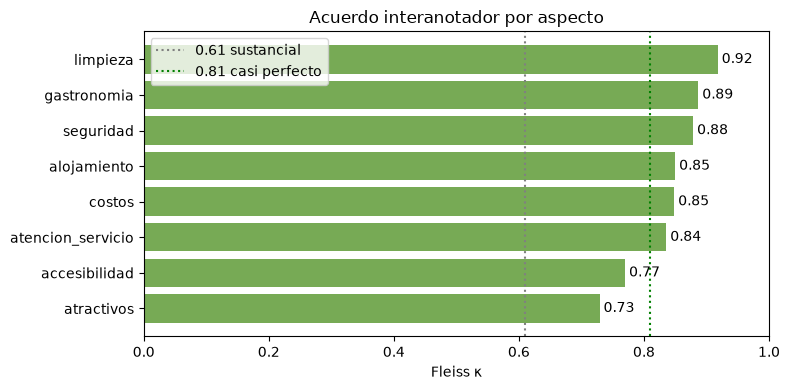

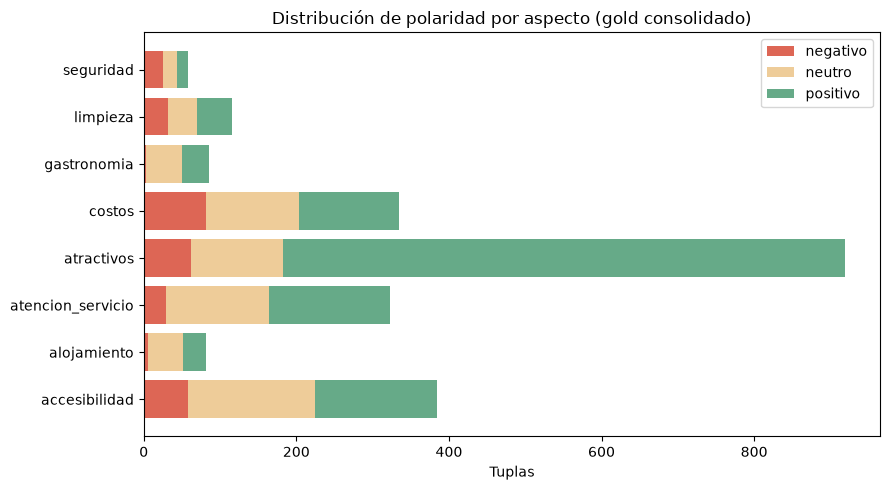

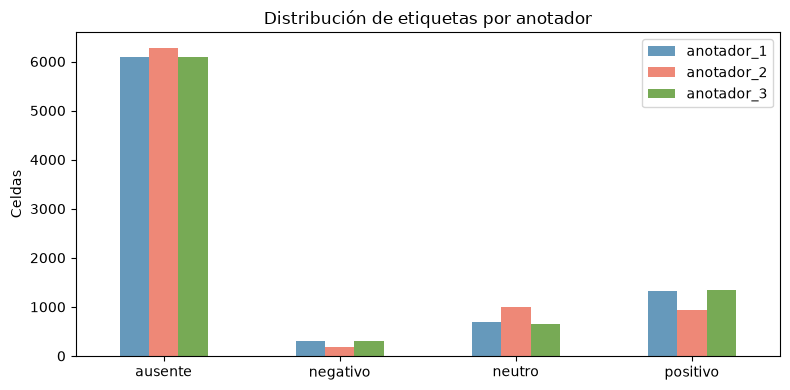

Figuras NB02 -> outputs/figures/


In [10]:
# ============================================================
# VISUALIZACIONES (figuras para la tesis)
# ============================================================
import matplotlib.pyplot as plt
FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

# 1) Fleiss κ por aspecto
ka = kappa_aspecto.sort_values("fleiss_kappa")
plt.figure(figsize=(8, 4)); plt.barh(ka["aspecto"], ka["fleiss_kappa"], color="#77aa55")
plt.axvline(0.61, color="gray", ls=":", label="0.61 sustancial")
plt.axvline(0.81, color="green", ls=":", label="0.81 casi perfecto")
for i, v in enumerate(ka["fleiss_kappa"]): plt.text(v, i, f" {v:.2f}", va="center")
plt.xlim(0, 1); plt.xlabel("Fleiss κ"); plt.title("Acuerdo interanotador por aspecto")
plt.legend(); plt.tight_layout(); plt.savefig(FIG / "fase2_kappa_por_aspecto.png", dpi=300); plt.show()

# 2) Distribución de polaridad por aspecto (apilado)
tb = tabla.drop(columns=[c for c in ["total"] if c in tabla.columns])
asp = tb.index.tolist(); bottom = np.zeros(len(asp))
plt.figure(figsize=(9, 5))
for lab, col in [("negativo", "#dd6655"), ("neutro", "#eecc99"), ("positivo", "#66aa88")]:
    vals = tb[lab].values if lab in tb.columns else np.zeros(len(asp))
    plt.barh(asp, vals, left=bottom, label=lab, color=col); bottom += vals
plt.xlabel("Tuplas"); plt.title("Distribución de polaridad por aspecto (gold consolidado)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG / "fase2_polaridad_por_aspecto.png", dpi=300); plt.show()

# 3) Distribución de etiquetas por anotador
dt = dist.reindex(CATEGORIAS)
dt.plot(kind="bar", figsize=(8, 4), color=["#6699bb", "#ee8877", "#77aa55"])
plt.title("Distribución de etiquetas por anotador"); plt.ylabel("Celdas"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG / "fase2_etiquetas_por_anotador.png", dpi=300); plt.show()
print("Figuras NB02 -> outputs/figures/")